
# Interfacing with QC Oracles (ORCA)

This tutorial demonstrates how to use the ``OrcaEngine`` to perform
quantum chemistry calculations.

The Oracle module acts as a bridge between your ML methods and
external computational chemistry software. We will explore two
distinct ways to set up and execute an ORCA calculation:
1. Defining fidelity parameters directly in Python.
2. Using a pre-defined ORCA input template file. (recommended for general use)


## Setting Up the Environment
First, let's create a temporary working directory and generate a simple
XYZ file for a water molecule that we can use for our calculations.



In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from mfml_qc.oracles import OrcaEngine

# this will be the working directory
workspace = "tutorial_workspace"
os.makedirs(workspace, exist_ok=True)

single_mol_xyz = os.path.join(workspace, "test_water.xyz")

# Write a dummy water molecule to an XYZ file
with open(single_mol_xyz, "w") as f:
    f.write("3\nWater test molecule\nO 0.000 0.000 0.000\n")
    f.write("H 0.000 0.757 0.587\nH 0.000 -0.757 0.587\n")

## Method 1: Dynamic Parameter Generation
The first way to run a calculation is to pass all your desired ORCA keywords
directly as a Python dictionary. The ``OrcaEngine`` will automatically
construct the `.inp` file for you.



In [2]:
fidelity_params_dynamic = {
    "method": "CAM-B3LYP",
    "basis": "def2-TZVP",
    "charge": 0,
    "multiplicity": 1,
    "nprocs": 2,  # Request 2 cores
    "maxcore": 2000,  # Allocate max 2000 MB memory per core
    "optional_tags": ["TightSCF", "RIJCOSX"],
    "EnGrad": None,  # we will not compute gradients (Forces)
    # We can inject multi-line blocks for complex tasks like TD-DFT:
    "custom_blocks": "%tddft\n  ETol 1e-6\n  RTol 1e-6\n  nroots 10\nend",
}

# Initialize the engine.
# NOTE: Update 'orca_path' to point to your actual ORCA binary,
# e.g., '/opt/orca_5_0_3_linux_x86-64_openmpi411/orca'
orca_engine_1 = OrcaEngine(
    orca_path="/../../../../opt/orca_5_0_3_linux_x86-64_openmpi411/orca"
)


try:
    # We set clean=False so we can inspect the generated files later.
    # return_outs=False means the engine will run but won't parse it automatically.
    orca_engine_1.evaluate(
        geometry=single_mol_xyz,
        fidelity_params=fidelity_params_dynamic,
        work_dir=os.path.join(workspace, "orca_dynamic"),
        return_outs=False,
        clean=False,
    )

    # We can manually define what to extract and parse the output file afterward:
    orca_engine_1.properties_to_extract = {"Total Energy": "FINAL SINGLE POINT ENERGY"}
    results_1 = orca_engine_1.parse_output(
        os.path.join(workspace, "orca_dynamic", "calc.out")
    )
    print("Extracted Properties:", results_1)

    # let's also take a look at the input file generated:
    with open(os.path.join(workspace, "orca_dynamic", "calc.inp"), "r") as f:
        print("\nGenerated Input File:\n", f.read())


# in case you do not have ORCA installed you can still see the input file generated
except FileNotFoundError:
    print("ORCA executable not found in PATH! Skipping calculation execution.")
    print("However, the engine successfully generated the input file!")

    # Let's peek at the file it generated for us:
    with open(os.path.join(workspace, "orca_dynamic", "calc.inp"), "r") as f:
        print("\nGenerated Input File:\n", f.read())

Extracted Properties: {'success': True, 'Total Energy': -76.154551278952}

Generated Input File:
 ! CAM-B3LYP def2-TZVP TightSCF RIJCOSX
%maxcore 2000
%PAL nproc 2 end
%tddft
  ETol 1e-6
  RTol 1e-6
  nroots 10
end

* xyzfile 0 1 /home/vvinod/MFML/docs/source/auto_examples/tutorial_workspace/test_water.xyz



## Method 2: Using an Input Template
If you have complex calculations with extensive blocks in your input files, you can simply
write an ORCA template file on your local machine. The ``OrcaEngine`` will read
this template and dynamically append the molecular geometry block at the bottom.

For example, you would create a file named ``TZVP_template.inp`` in your
directory with the following contents:

```text
! CAM-B3LYP def2-TZVP  def2/J TightSCF RIJCOSX EnGrad
#%maxcore 2000
%PAL nproc 2 end
%tddft
   ETol 1e-6
   RTol 1e-6
   nroots 10
   maxdim 100
   tprint 1E-10
   triplets false
end
```
For the sake of this automated tutorial, we will write this string to a temporary file for you:



In [3]:
template_file = os.path.join(workspace, "TZVP_template.inp")

# notice that we will now ask for the energy gradients (with EnGrad keyword)
template_content = """! CAM-B3LYP def2-TZVP  def2/J TightSCF RIJCOSX EnGrad
#%maxcore 2000
%PAL nproc 2 end
%tddft
   ETol 1e-6
   RTol 1e-6
   nroots 10
   maxdim 100
   tprint 1E-10
   triplets false
end
"""
with open(template_file, "w") as f:
    f.write(template_content)

fidelity_params_template = {
    "template_file": template_file,
    "charge": 0,
    "multiplicity": 1,
}

# Define the exact text labels to search for in the ORCA output file
advanced_properties = {
    "e_scf": "E(SCF)  =",
    "de_cis": "DE(CIS) =",
    "e_tot": "E(tot)  =",
    "e_final": "FINAL SINGLE POINT ENERGY",
}

# Initialize a new engine, passing the properties we want to extract upfront
orca_engine_2 = OrcaEngine(
    orca_path="/../../../../opt/orca_5_0_3_linux_x86-64_openmpi411/orca",
    properties_to_extract=advanced_properties,
)

orca_ran_successfully = False

try:
    # By setting return_outs=True, evaluate() automatically parses the output!
    results_2 = orca_engine_2.evaluate(
        geometry=single_mol_xyz,
        fidelity_params=fidelity_params_template,
        work_dir=os.path.join(workspace, "orca_template"),
        clean=False,
        return_outs=True,
    )
    print("Parsed Results:", results_2)

    # %%
    # Parsing Spectra and Gradients
    # -----------------------------
    # Because we included 'EnGrad' and '%tddft' in our template, ORCA generates
    # gradients and absorption spectra. We can manually call the parser on the
    # generated output file to extract these advanced arrays!

    output_path = os.path.join(workspace, "orca_template", "calc.out")
    results_advanced = orca_engine_2.parse_output(
        output_file=output_path, parse_gradients=True, parse_spectra=True
    )

    if "gradients" in results_advanced:
        print("First atom gradients (x, y, z):", results_advanced["gradients"][0])

    if "tddft_spectrum" in results_advanced:
        # The spectrum is returned as a list of state dictionaries
        state_1 = results_advanced["tddft_spectrum"][0]
        print("\nTD-DFT State 1:")
        for key, val in state_1.items():
            print(f"  {key}: {val}")

    orca_ran_successfully = True

except FileNotFoundError:
    print("ORCA executable not found in PATH! Skipping calculation execution.")
    with open(os.path.join(workspace, "orca_template", "calc.inp"), "r") as f:
        print("\nGenerated Template Input File:\n", f.read())

Parsed Results: {'success': True, 'e_scf': -76.434968286, 'de_cis': 0.280417007, 'e_tot': -76.154551279, 'e_final': -76.154551278952}
First atom gradients (x, y, z): [ 5.50000000e-11 -1.13160000e-08  9.11508225e-02]

TD-DFT State 1:
  state: 1
  energy_cm1: 61544.4
  wavelength_nm: 162.5
  fosc: 0.034215932
  px: 0.42782
  py: 0.0
  pz: 0.0


## Visualizing the Oracle Results
Let's visualize the target water molecule. If ORCA successfully executed on
your machine, we will overlay the computed properties (Energy, Gradients,
and TD-DFT spectra) directly onto the plot!



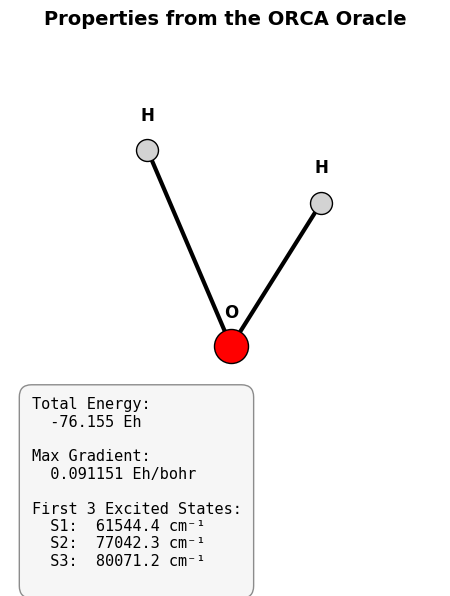

In [4]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

# coordinates of our test water molecule
coords = np.array(
    [
        [0.000, 0.000, 0.000],  # Oxygen
        [0.000, 0.757, 0.587],  # Hydrogen
        [0.000, -0.757, 0.587],  # Hydrogen
    ]
)
atoms = ["O", "H", "H"]
colors = ["red", "lightgrey", "lightgrey"]
sizes = [600, 250, 250]

# Plot the atoms
for i in range(3):
    ax.scatter(
        coords[i, 0],
        coords[i, 1],
        coords[i, 2],
        c=colors[i],
        s=sizes[i],
        edgecolors="k",
        depthshade=False,
        zorder=5,
    )
    # Add small text labels next to atoms
    ax.text(
        coords[i, 0],
        coords[i, 1],
        coords[i, 2] + 0.1,
        atoms[i],
        fontsize=12,
        ha="center",
        weight="bold",
        zorder=10,
    )

# Draw bonds (O-H)
ax.plot(
    [coords[0, 0], coords[1, 0]],
    [coords[0, 1], coords[1, 1]],
    [coords[0, 2], coords[1, 2]],
    "k-",
    lw=3,
    zorder=1,
)
ax.plot(
    [coords[0, 0], coords[2, 0]],
    [coords[0, 1], coords[2, 1]],
    [coords[0, 2], coords[2, 2]],
    "k-",
    lw=3,
    zorder=1,
)

ax.set_axis_off()
ax.set_title("Properties from the ORCA Oracle", fontsize=14, weight="bold", pad=20)
ax.view_init(elev=20, azim=45)

# text box of properties
text_str = ""
if orca_ran_successfully and results_2.get("success", False):
    energy = results_2.get("e_final", "N/A")
    text_str += f"Total Energy:\n  {energy:.3f} Eh\n\n"

    if "gradients" in results_advanced:
        max_grad = np.max(np.abs(results_advanced["gradients"]))
        text_str += f"Max Gradient:\n  {max_grad:.6f} Eh/bohr\n\n"

    if "tddft_spectrum" in results_advanced:
        text_str += "First 3 Excited States:\n"
        for state in results_advanced["tddft_spectrum"][:3]:
            text_str += f"  S{state['state']}: {state['energy_cm1']:>8.1f} cm⁻¹\n"
else:
    text_str += "ORCA Binary Not Found.\nDisplaying Geometry Only."

props = dict(
    boxstyle="round,pad=0.8", facecolor="whitesmoke", alpha=0.9, edgecolor="gray"
)
ax.text2D(
    0.05,
    0.2,
    text_str,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=props,
    family="monospace",
)

plt.tight_layout()
plt.show()

# Clean up our tutorial workspace
# comment this line if you wish to see what ORCA produced
shutil.rmtree(workspace)